# 04 — M2/L3: FRC Crossing with Standardized Effect Sizes by Demographic

**Pipeline stage:** the inferential follow-up to M2 Level&nbsp;3. A Wilcoxon p-value tells you the
*sign* of the above→below-FRC shift is reliable, but not whether the shift is large relative to its
own spread. This notebook adds **Cohen's d**, robust d, bootstrap CIs, sign-consistency, and a
**demographic stratification** (Young/Elder × Male/Female).

**Scripts reproduced**
| Script | Role |
|--------|------|
| `scripts/analyze_l3_stratified.py` | segment collection, effect sizes, forest & stratified histograms |
| `pneumophonic_analysis/effect_size.py` | `compute_paired_effect_size` (Cohen's d, robust d, Wilcoxon r, bootstrap CIs) |
| `scripts/make_m2_summary_plots.py` | Cohen's-d comparison bar chart, orthogonality scatter |

> **Plot types:** forest plot (median + bootstrap CI), 2×2 stratified histograms,
> grouped Cohen's-d bar chart with qualitative reference lines, orthogonality scatter with group medians.

## 0. Setup

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "scripts"))

import analyze_l3_stratified as l3
from analyze_l3_stratified import STRATA_ORDER, FRC_TASKS, FEATURES, UNITS
from make_m2_summary_plots import DEMO_COLORS
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

PAIRED_DIR = REPO / "data_target" / "healthy_subjects" / "paired"
META_PATH  = REPO / "data_root" / "healthy_subjects" / "subjects_metadata.csv"
print("FRC tasks:", FRC_TASKS, "| features:", FEATURES)

FRC tasks: ['a_2', 'a_3', 'a_7'] | features: ['f0', 'energy', 'pct_rc', 'flow_cw']


## 1. Collect FRC-split segments
`l3.collect_paired_segments` walks the sustained-task HDF5 files, splits each at the FRC crossing,
computes above/below feature means, and joins subject sex/age.

In [2]:

metadata = l3.load_metadata(META_PATH)
seg_df = l3.collect_paired_segments(PAIRED_DIR, metadata, tasks=FRC_TASKS)
seg_df = l3.assign_demographic_group(seg_df.dropna(subset=['sex', 'age']), age_threshold=55)
print(f"{len(seg_df)} segments | {seg_df['subject_id'].nunique()} subjects")
print("Demographics:", seg_df['demographic'].value_counts().to_dict())
seg_df[['subject_id','task','demographic','f0_above','f0_below','pct_rc_above','pct_rc_below']].head()

2026-06-10 19:24:00,635 - analyze_l3_stratified - INFO - Found 546 paired HDF5 files in C:\Users\Matéo\OneDrive\Documents\GitHub\pneumophonic_pipeline\data_target\healthy_subjects\paired
2026-06-10 19:24:05,906 - analyze_l3_stratified - INFO - Segments: kept=66  skipped_task=439  skipped_split=14  skipped_voiced=27
2026-06-10 19:24:06,016 - analyze_l3_stratified - WARNING - No metadata for 1 subject(s): ['CaBl']. They will be excluded from stratified analysis.


64 segments | 36 subjects
Demographics: {'YM': 18, 'EM': 17, 'EF': 15, 'YF': 14}


,subject_id,task,demographic,f0_above,f0_below,pct_rc_above,pct_rc_below
0,AlMo,a_7,YM,119.750526,184.953492,0.700858,0.701388
1,AnCa,a_7,EF,264.399284,340.677851,0.627837,0.631239
2,AnGu,a_2,EM,131.338604,130.428586,0.726794,0.727745
3,AnGu,a_3,EM,109.935451,112.553906,0.729767,0.731522
4,AnGu,a_7,EM,110.358765,152.635763,0.720627,0.724782


## 2. Stratified effect-size table
`l3.stratified_effect_sizes` runs `compute_paired_effect_size` for each feature across the nine
strata. Below, the overall (`All`) row for every feature.

In [3]:

summaries = [l3.stratified_effect_sizes(seg_df, f, age_threshold=55) for f in FEATURES]
summary = pd.concat(summaries, ignore_index=True)
cols = ['feature','stratum','n_segments','median_shift','cohen_d','cohen_d_label',
        'sign_consistency','wilcoxon_p']
display(summary[summary['stratum']=='All'][cols].round(4).reset_index(drop=True))

,feature,stratum,n_segments,median_shift,cohen_d,cohen_d_label,sign_consistency,wilcoxon_p
0,f0,All,64,7.2304,0.7928,medium,0.8594,0.0000
1,energy,All,64,-0.0015,0.2445,small,0.5312,0.3846
2,pct_rc,All,64,0.0049,1.0662,large,0.9219,0.0000
3,flow_cw,All,64,0.0052,-0.1199,negligible,0.5156,0.9307


## 3. Forest plot — F0 shift across strata
Median below−above shift with bootstrap 95% CI; blue markers are Wilcoxon-significant (p<0.05),
Cohen's d and sign-consistency annotated on the right. This is the headline L3 figure.

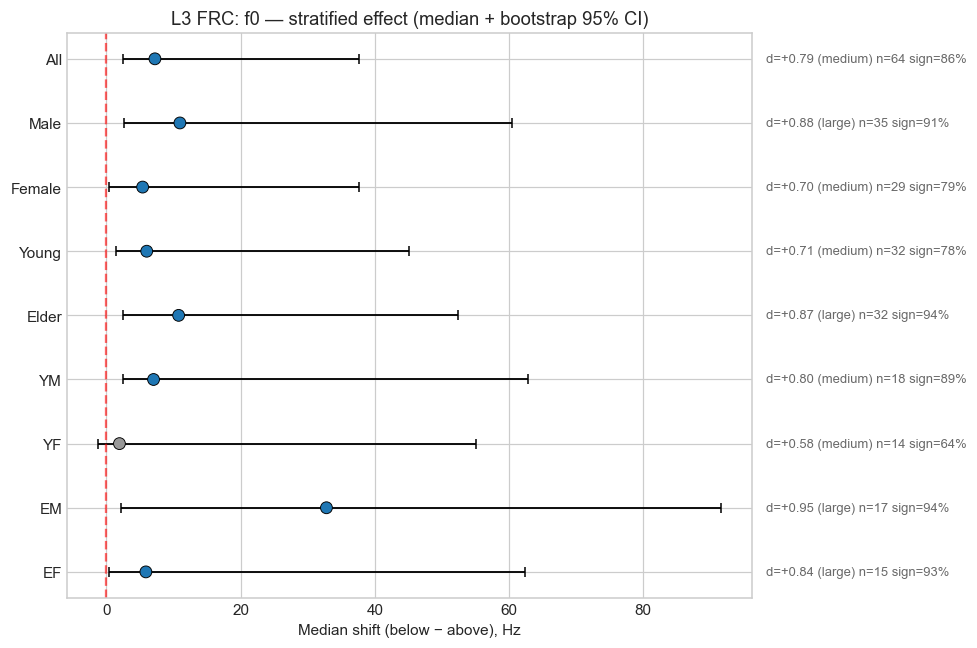

In [4]:

def forest(summary, feature):
    sub = summary[summary['feature']==feature].copy()
    sub['__o'] = sub['stratum'].apply(lambda s: STRATA_ORDER.index(s) if s in STRATA_ORDER else 99)
    sub = sub.sort_values('__o').reset_index(drop=True)
    y = np.arange(len(sub))
    med = sub['median_shift'].values
    elo = med - sub['median_ci_lo'].values; ehi = sub['median_ci_hi'].values - med
    fig, ax = plt.subplots(figsize=(9, 0.5*len(sub)+1.5))
    ax.errorbar(med, y, xerr=[elo, ehi], fmt='none', ecolor='black', elinewidth=1.2, capsize=3, zorder=2)
    colors = ['#1f77b4' if p < 0.05 else '#999999' for p in sub['wilcoxon_p']]
    ax.scatter(med, y, c=colors, s=60, edgecolor='black', linewidth=0.6, zorder=3)
    ax.axvline(0, color='red', ls='--', alpha=0.6)
    ax.set_yticks(y); ax.set_yticklabels(sub['stratum']); ax.invert_yaxis()
    ax.set_xlabel(f'Median shift (below − above), {UNITS.get(feature,"")}')
    ax.set_title(f"L3 FRC: {feature} — stratified effect (median + bootstrap 95% CI)")
    for i, r in enumerate(sub.itertuples()):
        ax.text(1.02, y[i], f"d={r.cohen_d:+.2f} ({r.cohen_d_label}) n={r.n_segments} sign={r.sign_consistency:.0%}",
                transform=ax.get_yaxis_transform(), va='center', fontsize=8.5, color='dimgray')
    plt.tight_layout(); plt.show()

forest(summary, 'f0')

### 3b. Forest plot — %RC shift
The rib-cage contribution shift; contrast its demographic pattern with F0 above.

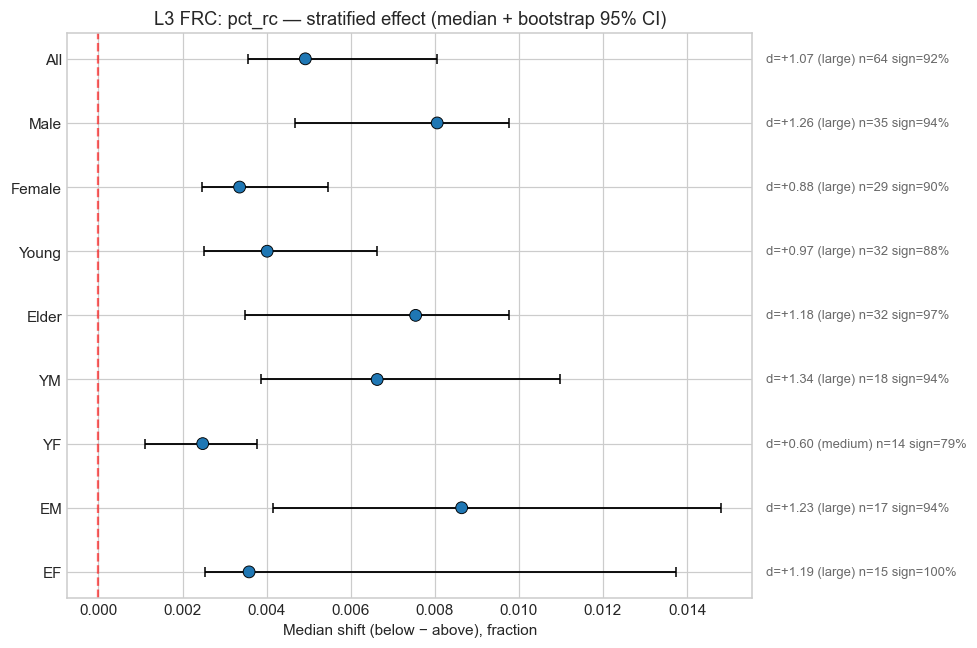

In [5]:
forest(summary, 'pct_rc')

## 4. Per-segment shift histograms by subgroup (F0)
2×2 small multiples — one panel per Young/Elder × Male/Female cell — of the raw per-segment
below−above shift, with median and Cohen's d annotated.

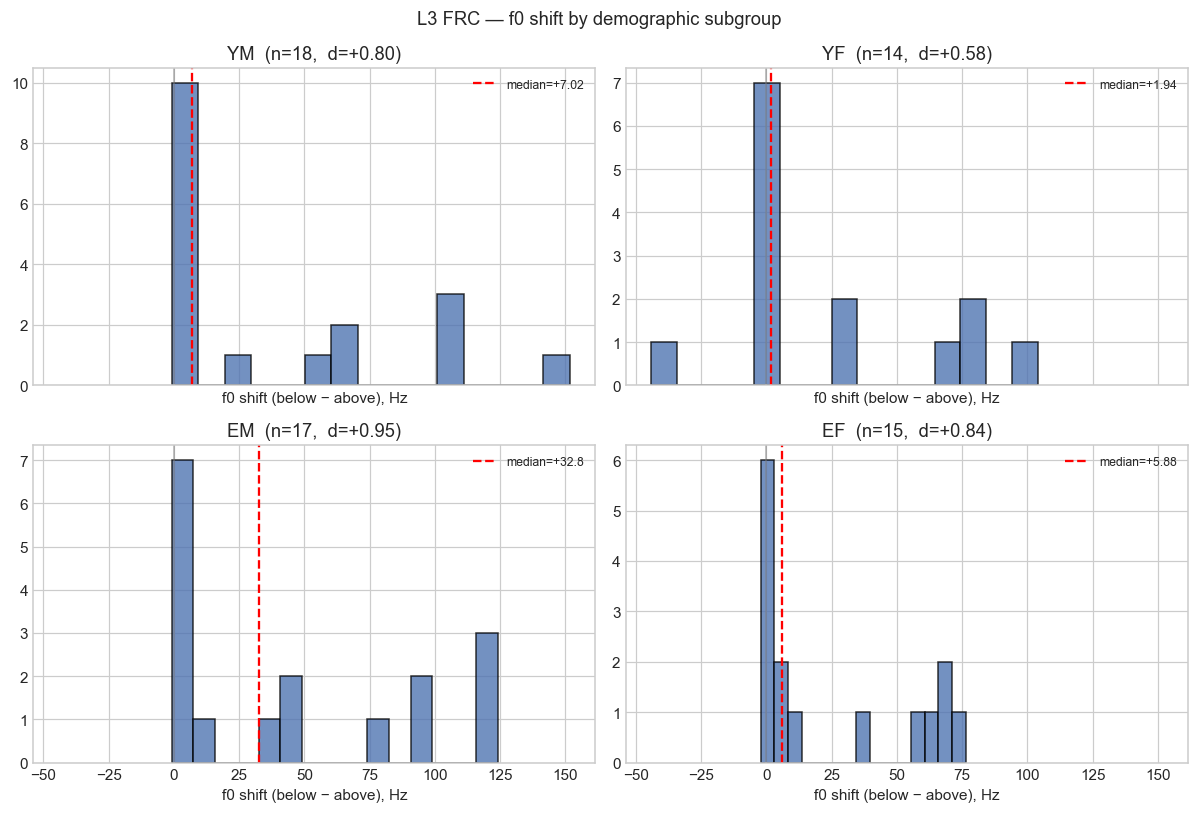

In [6]:

def strat_hist(seg_df, feature):
    df = l3.assign_demographic_group(seg_df.dropna(subset=['sex','age']), 55).copy()
    df['shift'] = df[f'{feature}_below'] - df[f'{feature}_above']
    df = df.dropna(subset=['shift'])
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
    for ax, g in zip(axes.flat, ['YM','YF','EM','EF']):
        s = df[df['demographic']==g]
        if len(s) >= 3:
            ax.hist(s['shift'], bins=15, color='#4c72b0', alpha=0.78, edgecolor='black')
            med = s['shift'].median(); sd = s['shift'].std(ddof=1)
            d = s['shift'].mean()/sd if sd>0 else np.nan
            ax.axvline(med, color='red', ls='--', lw=1.5, label=f'median={med:+.3g}')
            ax.axvline(0, color='gray', lw=1, alpha=0.6)
            ax.set_title(f'{g}  (n={len(s)},  d={d:+.2f})'); ax.legend(fontsize=8)
        else:
            ax.set_title(f'{g} (n={len(s)} — insufficient)')
        ax.set_xlabel(f'{feature} shift (below − above), {UNITS.get(feature,"")}')
    fig.suptitle(f'L3 FRC — {feature} shift by demographic subgroup', fontsize=12)
    plt.tight_layout(); plt.show()

strat_hist(seg_df, 'f0')

## 5. Cohen's d comparison across strata
Grouped bars (F0 vs %RC) for the nine strata, with Cohen's qualitative bins (small/medium/large)
as dotted reference lines. The headline of `make_m2_summary_plots.py`.

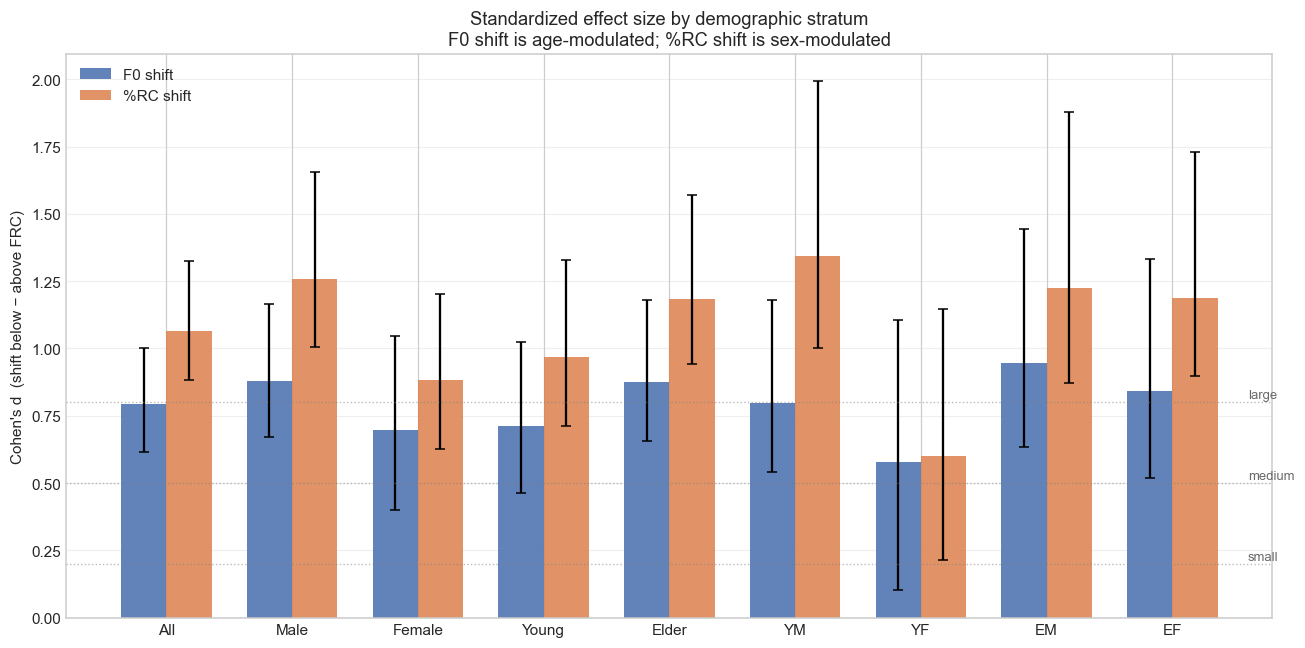

In [7]:

def aligned(feature):
    return summary[summary['feature']==feature].set_index('stratum').reindex(STRATA_ORDER)
f0, rc = aligned('f0'), aligned('pct_rc')
x = np.arange(len(STRATA_ORDER)); w = 0.36
def yerr(s): return np.vstack([s['cohen_d']-s['cohen_d_ci_lo'], s['cohen_d_ci_hi']-s['cohen_d']])

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x-w/2, f0['cohen_d'], w, yerr=yerr(f0), label='F0 shift', color='#4c72b0', alpha=0.88, capsize=3.5)
ax.bar(x+w/2, rc['cohen_d'], w, yerr=yerr(rc), label='%RC shift', color='#dd8452', alpha=0.88, capsize=3.5)
for d, lab in [(0.2,'small'),(0.5,'medium'),(0.8,'large')]:
    ax.axhline(d, color='gray', ls=':', alpha=0.55, lw=0.9)
    ax.text(len(x)-0.4, d+0.015, lab, fontsize=8.5, color='dimgray')
ax.axhline(0, color='black', lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(STRATA_ORDER)
ax.set_ylabel("Cohen's d  (shift below − above FRC)")
ax.set_title("Standardized effect size by demographic stratum\nF0 shift is age-modulated; %RC shift is sex-modulated")
ax.legend(loc='upper left', frameon=False); ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 6. Orthogonality scatter — F0 shift vs %RC shift
Each point is one sustained-phonation segment, coloured by demographic; the **X** markers are group
medians. The two axes carry largely independent demographic information (F0↔age, %RC↔sex).

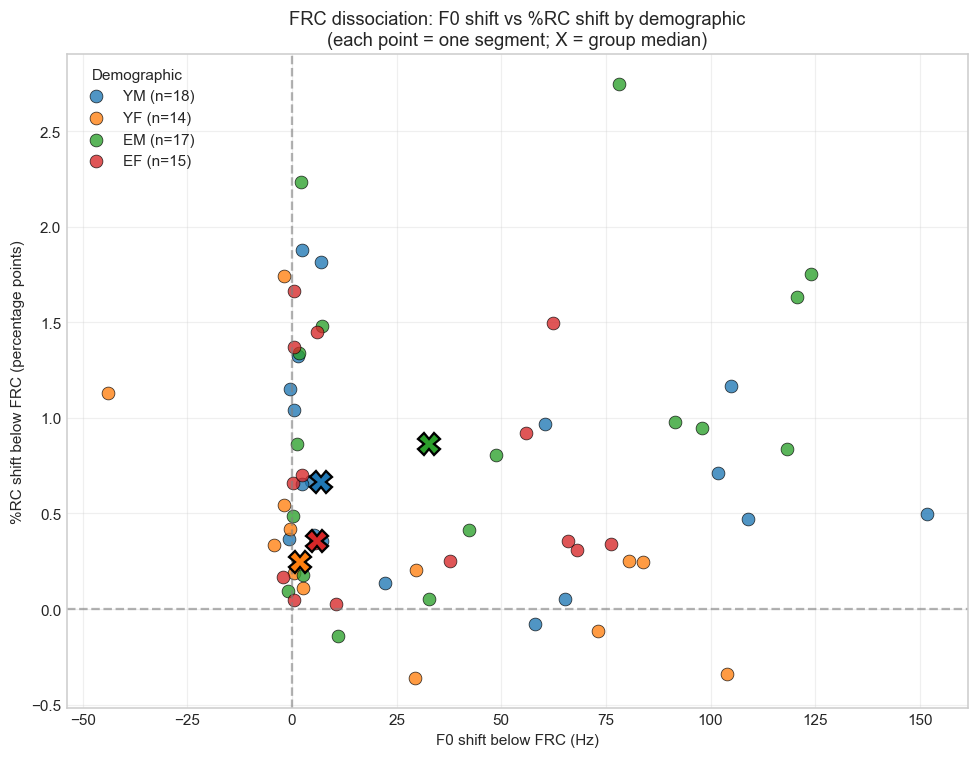

In [8]:

df = seg_df.dropna(subset=['demographic']).copy()
df['f0_shift'] = df['f0_below'] - df['f0_above']
df['pct_rc_shift_pp'] = (df['pct_rc_below'] - df['pct_rc_above']) * 100
df = df.dropna(subset=['f0_shift', 'pct_rc_shift_pp'])

fig, ax = plt.subplots(figsize=(9, 7))
for demo in ['YM','YF','EM','EF']:
    s = df[df['demographic']==demo]
    if len(s)==0: continue
    ax.scatter(s['f0_shift'], s['pct_rc_shift_pp'], c=DEMO_COLORS[demo],
               label=f'{demo} (n={len(s)})', alpha=0.78, s=70, edgecolor='black', linewidth=0.5)
    if len(s) >= 3:
        ax.plot(s['f0_shift'].median(), s['pct_rc_shift_pp'].median(), marker='X', markersize=14,
                color=DEMO_COLORS[demo], markeredgecolor='black', markeredgewidth=1.5, zorder=5)
ax.axhline(0, color='gray', ls='--', alpha=0.6); ax.axvline(0, color='gray', ls='--', alpha=0.6)
ax.set_xlabel('F0 shift below FRC (Hz)'); ax.set_ylabel('%RC shift below FRC (percentage points)')
ax.set_title("FRC dissociation: F0 shift vs %RC shift by demographic\n(each point = one segment; X = group median)")
ax.legend(title='Demographic', loc='upper left'); ax.grid(alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## Recap
Standardized effect sizes turn the L3 "is the shift real?" question into "how big, and for whom?".
To regenerate the full Excel summary + PDF forest/histogram set and the summary plots:

```bash
python scripts/analyze_l3_stratified.py --paired-dir data_target/healthy_subjects/paired     --metadata data_root/healthy_subjects/subjects_metadata.csv --output-dir results/M2_stratified
python scripts/make_m2_summary_plots.py --results-dir results/M2_stratified
```

Notebooks **05** and **06** move to M3: trying to *predict* the respiratory state from audio.